In [1]:
import numpy as np
from numpy.lib.recfunctions import structured_to_unstructured

import matplotlib.pyplot as plt

from astropy.table import Table, hstack, join
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 13})

In [2]:
results = {}

names = [f"train_fuji+guadalupe_v{i}_log_6_layers-val-best_valresults.fits" for i in [0, 1, 2]]
names.append("train_dr12_6_layers-val-best_valresults.fits")
for n in names:
    results[n.replace("_valresults.fits", "")] = Table.read(f"data/{n}")

truth_tbl = Table.read("data/desi_vi_blanc+qnet_2_truth_expanded_combined_fixed.csv")

In [3]:
line_names = np.asarray(["LYA", "CIV", "CIII", "MgII", "HBETA", "HALPHA", "CIV_BAL"])
c_names = [f"C_{l}" for l in line_names]

In [4]:
thresh_vals = np.linspace(0, 1, 1000)
n_thresh = 1

com = {n: np.zeros_like(thresh_vals) for n in results.keys()}
pur = {n: np.zeros_like(thresh_vals) for n in results.keys()}
for n in results.keys():
    joined = join(results[n], truth_tbl, "TARGETID")
    vi_qso = joined["VI_CLASS"] == "QSO"
    
    for k, c_thresh in enumerate(thresh_vals):
        c_line = structured_to_unstructured(np.asarray(joined[c_names]))
        is_qso_new = np.sum(c_line > c_thresh, axis=1) >= n_thresh

        # in_z_range = (joined["VI_Z"] >= z_bins[j]) & (joined["VI_Z"] < z_bins[j + 1])
        correct = is_qso_new & vi_qso

        com[n][k] = np.sum(correct) / np.sum(vi_qso)
        pur[n][k] = np.sum(correct) / np.sum(is_qso_new)


/tmp/ipykernel_541132/3518915236.py:18: RuntimeWarning: invalid value encountered in scalar divide
  pur[n][k] = np.sum(correct) / np.sum(is_qso_new)


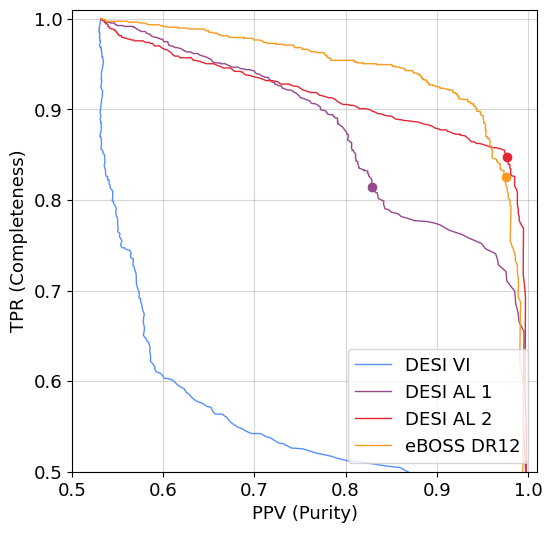

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
colors = ["#5790fc", "#964a8b", "#e42536", "#f89c20"]
labels = ["DESI VI", "DESI AL 1", "DESI AL 2", "eBOSS DR12"]
for i, n in enumerate(results.keys()):
    # if i < 2: continue
    ax.plot(pur[n], com[n], c=colors[i], label=labels[i], lw=1)
    
# for n in results.keys():
    joined = join(results[n], truth_tbl, "TARGETID")
    vi_qso = joined["VI_CLASS"] == "QSO"
    for c_thresh in [0.95]:
        c_line = structured_to_unstructured(np.asarray(joined[c_names]))
        is_qso_new = np.sum(c_line > c_thresh, axis=1) >= n_thresh
        correct = is_qso_new & vi_qso

        # Unfortunately need to recalc these for these specific confidence cuts.
        c = np.sum(correct) / np.sum(vi_qso)
        p = np.sum(correct) / np.sum(is_qso_new)

        marker = "X" if c_thresh == 0.5 else "o"
        ax.scatter(p, c, c=colors[i], marker=marker)    

ax.grid(alpha=0.5)
xmin, xmax = 0.5, 1.01
plt.legend()
ax.set(ylabel="TPR (Completeness)", xlabel="PPV (Purity)", xlim=(xmin, xmax), ylim=(xmin, xmax))
plt.savefig("plots/roc.pdf", bbox_inches="tight")